Loaded bare ansatz: 8 qubits, 3 params, 3 RZX, 3 cross-chip 2Q gates  (HF_8q_3doubles_rzx.json)
0: ───Rx(0.5π)───@──────────────────────────────────────────────────@───Rx(-0.5π)───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                 │                                                  │
1: ───H──────────@───H───@──────────────────────────────────@───H───@───H───────────Rx(0.5π)───@──────────────────────────────@───Rx(-0.5π)─────────────────────────────────────────────────────────────────
                         │                                  │                                  │                              │
2: ───H──────────────────@───@───────X──────────────────────@──────────────────────────────────@───X──────────────────────@───@───H───────────Rx(0.5π)───H───@───X──────────────────────@───H───Rx(-0.5π)───
                             │       │                                                     

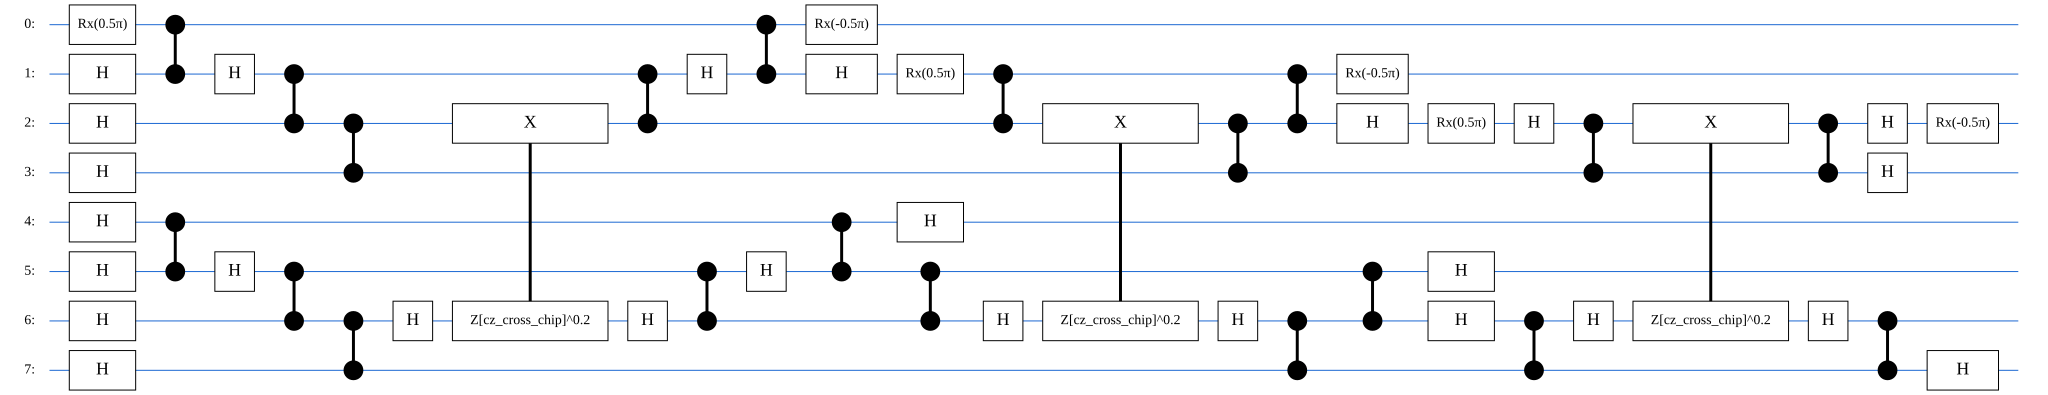

In [1]:
# This cell is to read the circuit from the file 
# and set up some basic parameters and mole
from __future__ import annotations

import cirq
import numpy as np
from cirq.ops import GlobalPhaseGate

# Needed for text/SVG diagrams: top-level ``cirq.GlobalPhaseGate`` can be missing in some kernels.
setattr(cirq, "GlobalPhaseGate", GlobalPhaseGate)
import sympy
from IPython.display import display

from cirq.contrib.svg import SVGCircuit

# Shared sampling/CDR settings used across later notebook cells.
GLOBAL_NUM_SHOTS = 8192
CDR_NUM_TRAINING_CIRCUITS = 30
CDR_T_MAX_GRADIENT = 2
CDR_T_MAX_VQE = CDR_T_MAX_GRADIENT
CDR_BASE_SEED = 42
GLOBAL_RANDOM_SEED = 1234
GLOBAL_SAMPLING_SEED = 1234
GLOBAL_MEASUREMENT_SCHEME = "ogm"
GLOBAL_APPLY_READOUT_NOISE = True
GLOBAL_READOUT_P0_SUCCESS = np.array([0.97, 0.96, 0.93, 0.96, 0.92, 0.93, 0.94, 0.92])
GLOBAL_READOUT_P1_SUCCESS = np.array([0.85, 0.90, 0.88, 0.90, 0.86, 0.89, 0.87, 0.85])


import json
from pathlib import Path

# Which molecule / bond length to load. The circuit JSON is produced by the
# molecule notebook (e.g. UCCSD_Mole/HF.ipynb) via uccsd_circuit_io.build_and_save.
MOLECULE = "HF"
BOND_LENGTH = 1.2
bond_length = BOND_LENGTH  # alias used by later cells (OGM / Hamiltonian paths)

# Active space for the loaded molecule. These MUST match the molecule notebook
# that produced the circuit / Hamiltonian (e.g. UCCSD_Mole/HF.ipynb uses 6
# electrons in 4 spatial orbitals for HF). They drive the HF-determinant
# reference and the qubit-count sanity checks below.
N_ACTIVE_ELECTRONS = 6              # active electrons
N_SPATIAL_ORBITALS = 4             # active spatial orbitals
N_QUBITS = 2 * N_SPATIAL_ORBITALS  # spin-orbitals == qubits
ETA = N_ACTIVE_ELECTRONS // 2      # occupied spatial orbitals per spin sector

_repo = Path.cwd().resolve()
while not (_repo / "June_main").is_dir() and _repo != _repo.parent:
    _repo = _repo.parent
CIRCUITS_DIR = _repo / "June_main" / "circuits2read"

# Make the shared library importable from this first cell (later cells repeat this).
import sys as _sys
for _p in (str(_repo / "June_main"), str(_repo)):
    if _p not in _sys.path:
        _sys.path.insert(0, _p)
# Parameterized native cross-chip RZX gate (supports sympy angles + resolution and
# is recognized by the CDR Clifford-snapping in main_cursor_lib).
from main_cursor_lib import RZXGate
# Bare ansatz (NO initial-state prep), with cross-chip CZ already decomposed to
# the native RZX form. The reference state (HF / multireference) is prepended in
# the next cell, so this cell just reads + draws the ansatz to confirm it loaded.
CIRCUIT_NAME = "HF_8q_3doubles_rzx"
CIRCUIT_JSON = CIRCUITS_DIR / f"{CIRCUIT_NAME}.json"

# Cross-chip two-qubit gates carry this tag so the noise model can apply a higher
# (cross-chip) depolarizing probability.
CZ_CROSS_CHIP_TAG = "cz_cross_chip"

# Which qubit pairs physically span two chips. The circuit JSON no longer carries
# a per-gate "cross_chip" flag; instead, ANY two-qubit gate acting on one of these
# (qubit_i, qubit_j) line-qubit index pairs is treated as a cross-chip link and
# gets the higher CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB noise. Order does not
# matter: (3, 4) and (4, 3) are the same link. Edit this to match the chip layout.
# In HF_8q_3doubles_rzx.json the native RZX entanglers act on qubits 2 and 6, so
# that is the cross-chip link here.
CROSS_CHIP_QUBIT_PAIRS = {(2, 6)}
_CROSS_CHIP_PAIR_SET = {frozenset(pair) for pair in CROSS_CHIP_QUBIT_PAIRS}


def _is_cross_chip_pair(qubit_indices):
    """True if the (unordered) qubit-index pair is a configured cross-chip link."""
    return frozenset(qubit_indices) in _CROSS_CHIP_PAIR_SET


def load_circuit_from_json(path):
    """Build a cirq.Circuit (LineQubit layout) from a saved UCCSD circuit JSON.

    Returns (circuit, qubits, symbols, meta). ANY two-qubit gate (CZ, RZX, CX, ...)
    whose qubit pair is listed in ``CROSS_CHIP_QUBIT_PAIRS`` is tagged with
    ``CZ_CROSS_CHIP_TAG`` so it gets the higher cross-chip depolarizing noise.
    Parameterized RX/RZ/RZX angles use sympy symbols named ``th_<k>`` so the CDR
    Clifford-snapping in ``main_cursor_lib`` treats them as theta-like.
    """
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    n = int(data["num_qubits"])
    q = cirq.LineQubit.range(n)
    param_names = list(data["param_names"])
    # Some circuit JSONs (e.g. the RZX-native variant) leave ``param_names`` empty
    # but still reference params (``"param": "t0"``) on their gates. Recover the
    # parameter list from gate references, in order of first appearance.
    if not param_names:
        for g in data["gates"]:
            name = g.get("param")
            if name is not None and name not in param_names:
                param_names.append(name)
    sym = {name: sympy.Symbol(f"th_{i}") for i, name in enumerate(param_names)}
    syms = [sym[name] for name in param_names]

    c = cirq.Circuit()
    for g in data["gates"]:
        op = g["op"]
        qs = [q[i] for i in g["qubits"]]
        if op == "h":
            new_op = cirq.H(qs[0])
        elif op == "x":
            new_op = cirq.X(qs[0])
        elif op == "ry":
            new_op = cirq.ry(float(g["value"])).on(qs[0])
        elif op == "cx":
            new_op = cirq.CNOT(qs[0], qs[1])
        elif op == "cz":
            new_op = cirq.CZ(qs[0], qs[1])
        elif op == "rzx":
            # Native cross-chip gate kept as ONE 2-qubit op. The angle can be a
            # sympy symbol (parameterized ansatz) and is resolved later for VQE,
            # gradients and CDR -- just like the single-qubit rx/rz rotations.
            if "param" in g:
                rzx_angle = float(g.get("coeff", 1.0)) * sym[g["param"]]
            else:
                rzx_angle = float(g.get("angle", g.get("value", 0.0)))
            new_op = RZXGate(rzx_angle).on(qs[0], qs[1])
        elif op in ("rx", "rz"):
            angle = float(g["coeff"]) * sym[g["param"]] if "param" in g else float(g["value"])
            gate = cirq.rx if op == "rx" else cirq.rz
            new_op = gate(angle).on(qs[0])
        else:
            raise ValueError(f"Unhandled op in circuit JSON: {op!r}")

        # Gate-agnostic cross-chip tagging: ANY two-qubit gate (CZ, RZX, CX, ...)
        # acting on a cross-chip pair gets the tag, so the noise model applies the
        # higher CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB. The noise model only cares
        # that the op is 2-qubit and carries the tag -- not which gate it is.
        if len(new_op.qubits) == 2 and _is_cross_chip_pair(g["qubits"]):
            new_op = new_op.with_tags(CZ_CROSS_CHIP_TAG)
        c.append(new_op)
    return c, list(q), syms, data


circuit, qubits, symbols, circuit_meta = load_circuit_from_json(CIRCUIT_JSON)
# Bare ansatz handle: the next cell prepends the reference-state prep and rebinds
# ``circuit`` to (prep + ansatz). Keeping this separate makes that step idempotent.
ansatz_circuit = circuit
num_qubits = len(qubits)
n_params = len(symbols)
qubit_map = {qq: i for i, qq in enumerate(qubits)}

# Sanity-check the loaded circuit against the declared active space.
assert num_qubits == N_QUBITS, (
    f"Circuit has {num_qubits} qubits but active space implies "
    f"N_QUBITS={N_QUBITS} (= 2 * N_SPATIAL_ORBITALS={N_SPATIAL_ORBITALS})."
)
_meta_ne = circuit_meta.get("n_electrons")
if _meta_ne is not None:
    assert int(_meta_ne) == N_ACTIVE_ELECTRONS, (
        f"Circuit JSON n_electrons={int(_meta_ne)} != "
        f"N_ACTIVE_ELECTRONS={N_ACTIVE_ELECTRONS}."
    )


def resolver_from_params(params_vec):
    """Map a length-``n_params`` vector to a {symbol: value} resolver dict."""
    p = np.asarray(params_vec, dtype=float).reshape(n_params)
    return {symbols[i]: float(p[i]) for i in range(n_params)}


# Backward-compatible aliases for cells originally written for the 3-parameter LiH case.
symbols_li_h = symbols
if n_params >= 1:
    theta1 = symbols[0]
if n_params >= 2:
    theta2 = symbols[1]
if n_params >= 3:
    theta3 = symbols[2]

_n_cross = sum(
    1 for g in circuit_meta["gates"]
    if len(g["qubits"]) == 2 and _is_cross_chip_pair(g["qubits"])
)
_n_rzx = sum(1 for g in circuit_meta["gates"] if g["op"] == "rzx")
print(
    f"Loaded bare ansatz: {num_qubits} qubits, {n_params} params, "
    f"{_n_rzx} RZX, {_n_cross} cross-chip 2Q gates  ({CIRCUIT_JSON.name})"
)

# Diagram at θ = π/5 on every parameter (visualization only).
_theta_viz = np.pi / 5
resolver_viz = cirq.ParamResolver({s: _theta_viz for s in symbols})
circuit_draw = cirq.resolve_parameters(circuit, resolver_viz)

print(circuit_draw)
display(SVGCircuit(circuit_draw))

# --- Qiskit-style diagram (matches "UCCSD circuit/br2_16q_3doubles_circuit.png") ---
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit as _QiskitCircuit

# Qiskit "iqp" colours hard-coded so the look matches regardless of qiskit version:
# salmon H, blue X, maroon rotations, light-blue CZ links.
_IQP_STYLE = {
    "name": "iqp",
    "displaycolor": {
        "h": ["#FA4D56", "#000000"],
        "x": ["#002D9C", "#FFFFFF"],
        "rx": ["#9F1853", "#FFFFFF"],
        "ry": ["#9F1853", "#FFFFFF"],
        "rz": ["#33B1FF", "#000000"],
        "rzx": ["#33B1FF", "#000000"],
        "cz": ["#33B1FF", "#000000"],
        "cx": ["#002D9C", "#000000"],
    },
}


from qiskit.circuit import Parameter as _QiskitParameter


def _qiskit_circuit_from_meta(meta):
    # SAME code as the circuit generator's save_circuit_diagram /
    # qc_from_logical_gates: symbolic rotations keep their parameter name
    # (t0, t1, ...), so the look matches the PNGs saved in circuits2read
    # (e.g. HF_8q_3doubles_circuit.png).
    qcq = _QiskitCircuit(int(meta["num_qubits"]))
    _params: dict = {}

    def _angle(g):
        if "param" in g:
            p = _params.setdefault(g["param"], _QiskitParameter(g["param"]))
            return float(g.get("coeff", 1.0)) * p
        return float(g.get("value", g.get("angle", 0.0)))

    for g in meta["gates"]:
        op = g["op"].lower()
        qb = g["qubits"]
        if op == "x":
            qcq.x(qb[0])
        elif op == "h":
            qcq.h(qb[0])
        elif op == "cx":
            qcq.cx(qb[0], qb[1])
        elif op == "cz":
            qcq.cz(qb[0], qb[1])
        elif op == "rx":
            qcq.rx(_angle(g), qb[0])
        elif op == "ry":
            qcq.ry(_angle(g), qb[0])
        elif op == "rz":
            qcq.rz(_angle(g), qb[0])
        elif op == "rzx":
            qcq.rzx(_angle(g), qb[0], qb[1])
        else:
            raise ValueError(f"Unhandled op in circuit JSON: {op!r}")
    return qcq


_qcq = _qiskit_circuit_from_meta(circuit_meta)
# fold=-1 -> one continuous row (no wrapping), matching the reference PNG layout.
_fig = _qcq.draw(output="mpl", style=_IQP_STYLE, fold=-1)
_fig.suptitle(f"{CIRCUIT_NAME}", fontsize=14)
plt.show()

In [2]:
import sys
from pathlib import Path

# Repo root resolution for local file loading (root holds Pauli_Ham/ and June_main/).
_repo = Path.cwd().resolve()
while not (_repo / "Pauli_Ham").is_dir() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (str(_repo / "June_main"), str(_repo)):
    if _p not in sys.path:
        sys.path.insert(0, _p)


# Read numbered-Pauli Hamiltonian from Pauli_Ham/<MOLECULE>_bond_<bond>.txt.
def load_pauli_sum_from_numbered_file(path: Path, qubits: list[cirq.Qid]) -> cirq.PauliSum:
    idx_to_pauli = {1: cirq.X, 2: cirq.Y, 3: cirq.Z}
    out = cirq.PauliSum()

    with path.open("r", encoding="utf-8") as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.strip()
            if not line:
                continue

            parts = line.split()
            coeff = float(parts[0])
            pauli_codes = [int(x) for x in parts[1:]]

            if len(pauli_codes) != len(qubits):
                raise ValueError(
                    f"{path}:{lineno} has {len(pauli_codes)} Pauli indices, expected {len(qubits)}."
                )

            pauli_string = cirq.PauliString()
            for q, code in zip(qubits, pauli_codes):
                if code == 0:
                    continue
                if code not in idx_to_pauli:
                    raise ValueError(f"{path}:{lineno} has invalid Pauli code {code}; expected 0/1/2/3.")
                pauli_string *= idx_to_pauli[code](q)

            out += coeff * pauli_string

    return out


ham_path = _repo / "Pauli_Ham" / f"{MOLECULE}_bond_{bond_length:.1f}.txt"

# Hamiltonian + exact ground-state energy. The bare ansatz (no prep) is not a
# meaningful state by itself, so the reference energy of the FULL circuit is
# reported in the "Initial state preparation" cell once the prep is prepended.
pauli_sum = load_pauli_sum_from_numbered_file(ham_path, list(qubits))
qubit_map = {q: i for i, q in enumerate(qubits)}
e_gs = float(np.linalg.eigvalsh(pauli_sum.matrix(qubits=qubits))[0].real)

# HF determinant reference (X on the occupied spin-orbitals of this active
# space). Occupation comes from the explicit active-space inputs above
# (N_ACTIVE_ELECTRONS / N_SPATIAL_ORBITALS), not the circuit metadata.
_half = N_SPATIAL_ORBITALS
_eta = ETA
_occ = list(range(_eta)) + list(range(_half, _half + _eta))
psi_hf = cirq.Simulator().simulate(
    cirq.Circuit([cirq.X(qubits[k]) for k in _occ] or [cirq.I(q) for q in qubits]),
    qubit_order=qubits,
).final_state_vector
e_hf_ref = float(
    np.real(pauli_sum.expectation_from_state_vector(np.asarray(psi_hf, dtype=np.complex128), qubit_map=qubit_map))
)

print(
    f"\n{MOLECULE} bond {bond_length} Å  "
    f"(active space: {N_ACTIVE_ELECTRONS}e, {N_SPATIAL_ORBITALS}o -> {N_QUBITS} qubits)"
)
print(f"Hamiltonian source: {ham_path}")
print(f"⟨H⟩ HF determinant reference: {e_hf_ref:.10f} Eh")
print(f"Ground-state energy e_gs (exact): {e_gs:.10f} Eh")


HF bond 1.2 Å  (active space: 6e, 4o -> 8 qubits)
Hamiltonian source: /Users/zacharyhe/cross_chips_sim/Pauli_Ham/HF_bond_1.2.txt
⟨H⟩ HF determinant reference: -98.5230711309 Eh
Ground-state energy e_gs (exact): -98.5738783367 Eh


In [3]:
# === Initial state preparation: HF (default) or multireference ======
# Prepend the reference state to the bare ansatz loaded above, then rebind
# ``circuit`` to the full (prep + ansatz) circuit used by every later cell.
#   "hf"       -> Hartree-Fock determinant (X on the occupied spin-orbitals)
#   "multiref" -> paper Eq.(6) state (|HF> - beta|exc>)/sqrt(1+beta^2). The prep
#                 rotation Ry(alpha = -2*arctan(beta)) is optimized HERE by
#                 minimizing the noiseless <H> (no separate set-then-optimize).
INIT_STATE_METHOD = "hf"  # "hf" or "multiref"

from scipy.optimize import minimize_scalar

_half = N_SPATIAL_ORBITALS
_eta = ETA
_occupied = list(range(_eta)) + list(range(_half, _half + _eta))
_sim_prep = cirq.Simulator()


def hf_prep_circuit() -> cirq.Circuit:
    """HF determinant: X on each occupied spin-orbital."""
    return cirq.Circuit([cirq.X(qubits[k]) for k in _occupied])


def multiref_prep_circuit(alpha: float) -> cirq.Circuit:
    """Paper Eqs.(7)-(8): Ry(alpha) on q_{eta-1}, a 3-CNOT chain, then the HF X layer."""
    c = cirq.Circuit()
    c.append(cirq.ry(float(alpha)).on(qubits[_eta - 1]))
    c.append(cirq.CNOT(qubits[_eta - 1], qubits[_eta]))
    c.append(cirq.CNOT(qubits[_eta], qubits[_half + _eta - 1]))
    c.append(cirq.CNOT(qubits[_half + _eta - 1], qubits[_half + _eta]))
    c.append([cirq.X(qubits[k]) for k in _occupied])
    return c


def _prep_state_energy(prep: cirq.Circuit) -> float:
    psi = np.asarray(
        _sim_prep.simulate(prep, qubit_order=qubits).final_state_vector, dtype=np.complex128
    )
    return float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))


if INIT_STATE_METHOD == "hf":
    prep_circuit = hf_prep_circuit()
    multiref_alpha = None
    multiref_beta = None
    print("Initial state: Hartree-Fock determinant")
    print(f"  occupied spin-orbitals : {_occupied}")
elif INIT_STATE_METHOD == "multiref":
    # Combined choice + optimization: minimize <H> over the prep rotation alpha.
    _opt = minimize_scalar(
        lambda a: _prep_state_energy(multiref_prep_circuit(a)),
        bounds=(-np.pi, np.pi),
        method="bounded",
    )
    multiref_alpha = float(_opt.x)
    multiref_beta = float(-np.tan(multiref_alpha / 2.0))
    prep_circuit = multiref_prep_circuit(multiref_alpha)
    print("Initial state: multireference (paper Eq.6), beta optimized in this cell")
    print(f"  optimal alpha = {multiref_alpha:.6f} rad  ->  beta = {multiref_beta:.6f}")
else:
    raise ValueError(f"INIT_STATE_METHOD must be 'hf' or 'multiref', got {INIT_STATE_METHOD!r}")

# Full circuit = prep + bare ansatz. Rebuilt from ``ansatz_circuit`` every run so
# re-executing this cell is idempotent; rebind ``circuit`` for downstream cells.
circuit = prep_circuit + ansatz_circuit
n_params = len(symbols)  # prep adds no free parameters

# Reference energy of the full circuit at theta = 0 (= the chosen prep state).
_res0 = cirq.resolve_parameters(circuit, cirq.ParamResolver({s: 0.0 for s in symbols}))
_psi0 = np.asarray(
    cirq.Simulator().simulate(_res0, qubit_order=qubits).final_state_vector, dtype=np.complex128
)
e_prep_ref = float(np.real(pauli_sum.expectation_from_state_vector(_psi0, qubit_map=qubit_map)))

print(f"  ⟨H⟩ prep state (all θ=0)  : {e_prep_ref:.10f} Eh")
print(f"  ⟨H⟩ HF determinant ref    : {e_hf_ref:.10f} Eh")
print(f"  ground-state e_gs (exact) : {e_gs:.10f} Eh")
print(
    f"Full circuit ready: {len(list(circuit.all_operations()))} ops, "
    f"{n_params} params (downstream cells use `circuit`)."
)

Initial state: Hartree-Fock determinant
  occupied spin-orbitals : [0, 1, 2, 4, 5, 6]
  ⟨H⟩ prep state (all θ=0)  : -98.5230711309 Eh
  ⟨H⟩ HF determinant ref    : -98.5230711309 Eh
  ground-state e_gs (exact) : -98.5738783367 Eh
Full circuit ready: 61 ops, 3 params (downstream cells use `circuit`).


In [4]:
# Evaluate the compiled ansatz energy at the noiseless L-BFGS-B optimum
# (June_main/optimize_hf_3doubles_lbfgs.py, HF bond 2.2, Hartree-Fock prep).
params = np.array([0.0020292770, 0.0020329417, -4.9689013693], dtype=float)
resolver_test = cirq.ParamResolver(resolver_from_params(params))

resolved_test = cirq.resolve_parameters(circuit, resolver_test)
psi_test = np.asarray(
    cirq.Simulator(dtype=np.complex128).simulate(resolved_test, qubit_order=qubits).final_state_vector,
    dtype=np.complex128,
)
e_test = float(np.real(pauli_sum.expectation_from_state_vector(psi_test, qubit_map=qubit_map)))

print(f"params = {params.tolist()}")
print(f"E(params) = {e_test:.10f} Eh")

params = [0.002029277, 0.0020329417, -4.9689013693]
E(params) = -98.2057450856 Eh


In [5]:
# No measurement error here (density matrix + Tr[H ρ]).
# just noisy energy using trace of H * rho 
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
while not (_repo / "June_main" / "main_cursor_lib.py").is_file() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (str(_repo / "June_main"), str(_repo)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib import (
    GateArityDepolarizingNoise,
    CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    trace_energy,
)

random_seed = int(globals()["GLOBAL_RANDOM_SEED"])

gate_noise = GateArityDepolarizingNoise(
    two_qubit_depol_prob=TWO_QUBIT_GATE_DEPOL_PROB,
    one_qubit_depol_prob=ONE_QUBIT_GATE_DEPOL_PROB,
    cross_chip_two_qubit_depol_prob=CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
)
noisy_ansatz = circuit.with_noise(gate_noise)
resolver_noisy = cirq.ParamResolver(resolver_from_params(params))
resolved_noisy = cirq.resolve_parameters(noisy_ansatz, resolver_noisy)

rho_noisy = np.asarray(
    cirq.DensityMatrixSimulator(seed=random_seed)
    .simulate(resolved_noisy, qubit_order=qubits)
    .final_density_matrix,
    dtype=np.complex128,
)

hamiltonian_matrix = pauli_sum.matrix(qubits=qubits)
trace_noisy_energy = trace_energy(hamiltonian_matrix, rho_noisy)

print(
    f"noise: two_qubit_depol={gate_noise.two_qubit_depol_prob} "
    f"one_qubit_depol={gate_noise.one_qubit_depol_prob} "
    f"cross_chip_two_qubit_depol={gate_noise.cross_chip_two_qubit_depol_prob}"
)
print(f"params = {params.tolist()}")
print(f"Tr[H ρ_noisy] (gate noise only): {trace_noisy_energy:.10f} Eh")

noise: two_qubit_depol=0.01 one_qubit_depol=0.0005 cross_chip_two_qubit_depol=0.1
params = [0.002029277, 0.0020329417, -4.9689013693]
Tr[H ρ_noisy] (gate noise only): -97.7301196948 Eh


In [6]:
# Finite-shot energy from the same ``rho_noisy`` as above: OGM measurement layout + asymmetric
# readout (``p_0_success`` / ``p_1_success`` on LineQubit 0…5) and optional REM in post-processing.
# the OGM basis file is from the OGM_measurement_basis folder instead of old path from shadowgrouping folder
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
while not (_repo / "June_main" / "main_cursor_lib.py").is_file() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (str(_repo / "June_main"), str(_repo)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from shot_measurement import estimate_energy_from_noisy_rho_shots

num_shots = int(globals()["GLOBAL_NUM_SHOTS"])
measurement_scheme = str(globals()["GLOBAL_MEASUREMENT_SCHEME"])
sampling_seed = int(globals()["GLOBAL_SAMPLING_SEED"])
epsilon = 0.1

p_0_success = np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float)
p_1_success = np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float)

apply_readout_noise = bool(globals()["GLOBAL_APPLY_READOUT_NOISE"])
apply_rem = True

SHADOWGROUPING_ROOT = globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping")
ogm_file = globals().get(
    "ogm_file",
    _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_bond_{bond_length:.1f}.txt",
)

print(f"OGM file: {ogm_file}  exists={ogm_file.is_file()}")

if not ogm_file.is_file():
    print(
        "Skip OGM shot estimate: OGM file missing. Generate LiH OGM at this bond or set SHADOWGROUPING_ROOT."
    )
elif not Path(SHADOWGROUPING_ROOT).is_dir():
    print("Skip OGM shot estimate: SHADOWGROUPING_ROOT does not exist.")
else:
    try:
        shot_est = estimate_energy_from_noisy_rho_shots(
            rho_noisy,
            pauli_sum,
            qubits,
            num_shots=num_shots,
            measurement_scheme=measurement_scheme,
            p_0_success=p_0_success,
            p_1_success=p_1_success,
            apply_rem=apply_rem,
            apply_readout_noise=apply_readout_noise,
            sampling_seed=sampling_seed,
            epsilon=epsilon,
            ogm_file=ogm_file,
            shadowgrouping_root=SHADOWGROUPING_ROOT,
        )
        eu = float(shot_est["energy_unmitigated"])
        er = float(shot_est["energy_rem"])

        print(f"Finite-shot energy (readout noise, no REM correction): {eu:.12f} Eh")
        print(f"Finite-shot energy (REM readout mitigation):          {er:.12f} Eh")
        print(f"REM delta (REM - raw shots):                            {er - eu:.12f} Eh")
        print(
            f"\nReference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): {trace_noisy_energy:.12f} Eh"
        )
    except Exception:
        raise

OGM file: /Users/zacharyhe/cross_chips_sim/June_main/OGM_measurement_basis/OGM_HF_bond_1.2.txt  exists=True
Finite-shot energy (readout noise, no REM correction): -97.154459101877 Eh
Finite-shot energy (REM readout mitigation):          -97.778019407582 Eh
REM delta (REM - raw shots):                            -0.623560305705 Eh

Reference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): -97.730119694833 Eh


n_shots=   8192: mean(|REM-ref|)=4.940619e-02 Eh  std=3.223008e-02 Eh
n_shots=  16384: mean(|REM-ref|)=3.440012e-02 Eh  std=2.476852e-02 Eh
n_shots=  32768: mean(|REM-ref|)=3.318225e-02 Eh  std=2.302392e-02 Eh
n_shots=  81920: mean(|REM-ref|)=1.385020e-02 Eh  std=1.604105e-02 Eh


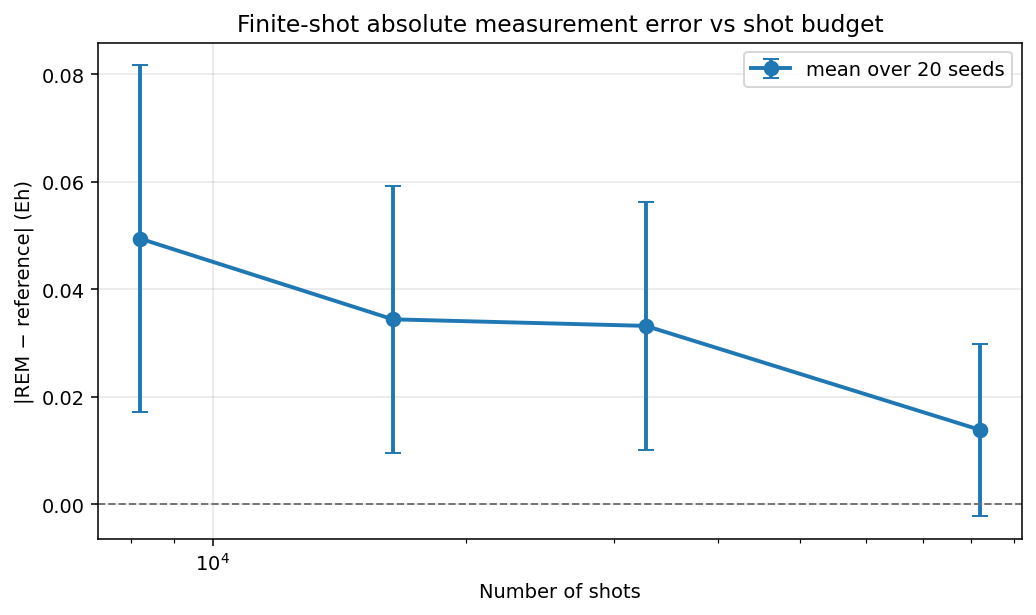

In [7]:
# Measurement error vs shot budget: mean(|REM - reference|) over independent shot seeds.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_repo = Path.cwd().resolve()
while not (_repo / "June_main" / "main_cursor_lib.py").is_file() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (str(_repo / "June_main"), str(_repo)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from shot_measurement import (
    estimate_energy_from_noisy_rho_shots,
    sanitize_density_matrix,
)

# Same shot/readout settings as the finite-shot cell above (LiH OGM + REM).
measurement_scheme = str(globals().get("measurement_scheme", globals()["GLOBAL_MEASUREMENT_SCHEME"]))
sampling_seed = int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"]))
epsilon = float(globals().get("epsilon", 0.1))
p_0_success = np.array(globals().get("p_0_success", globals()["GLOBAL_READOUT_P0_SUCCESS"]), dtype=float)
p_1_success = np.array(globals().get("p_1_success", globals()["GLOBAL_READOUT_P1_SUCCESS"]), dtype=float)
apply_readout_noise = bool(globals().get("apply_readout_noise", globals()["GLOBAL_APPLY_READOUT_NOISE"]))
apply_rem = bool(globals().get("apply_rem", True))

SHADOWGROUPING_ROOT = globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping")
ogm_file = globals().get(
    "ogm_file",
    _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_bond_{bond_length:.1f}.txt",
)

# Exact Tr[H rho_noisy] from the gate-noise DM cell (main.ipynb uses e_noisy_adj for the same role).
energy_reference = float(globals()["trace_noisy_energy"])

if not Path(ogm_file).is_file():
    print(f"Skip shot-budget sweep: OGM file missing ({ogm_file}).")
elif not Path(SHADOWGROUPING_ROOT).is_dir():
    print("Skip shot-budget sweep: SHADOWGROUPING_ROOT does not exist.")
else:
    rho_noisy_for_shots = sanitize_density_matrix(rho_noisy)

    shot_budgets = [
        8192,
        8192 * 2,
        8192 * 4,
        8192 * 10
    ]
    num_replicates = 20
    base_seed = int(globals().get("GLOBAL_SAMPLING_SEED", sampling_seed))

    mean_errors = []
    std_errors = []
    for n_shots in shot_budgets:
        errs = []
        for rep in range(num_replicates):
            est = estimate_energy_from_noisy_rho_shots(
                rho_noisy_for_shots,
                pauli_sum,
                list(qubits),
                num_shots=int(n_shots),
                measurement_scheme=measurement_scheme,
                p_0_success=p_0_success,
                p_1_success=p_1_success,
                apply_rem=apply_rem,
                apply_readout_noise=apply_readout_noise,
                sampling_seed=base_seed + rep,
                epsilon=epsilon,
                ogm_file=ogm_file,
                shadowgrouping_root=SHADOWGROUPING_ROOT,
            )
            errs.append(abs(float(est["energy_rem"]) - energy_reference))
        mean_errors.append(float(np.mean(errs)))
        std_errors.append(float(np.std(errs, ddof=1)))
        print(
            f"n_shots={n_shots:7d}: mean(|REM-ref|)={mean_errors[-1]:.6e} Eh  "
            f"std={std_errors[-1]:.6e} Eh"
        )

    fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=140)
    ax.errorbar(
        shot_budgets,
        mean_errors,
        yerr=std_errors,
        fmt="o-",
        capsize=4,
        lw=2,
        ms=7,
        color="tab:blue",
        label=f"mean over {num_replicates} seeds",
    )
    ax.axhline(0.0, color="0.45", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("Number of shots")
    ax.set_ylabel("|REM − reference| (Eh)")
    ax.set_title("Finite-shot absolute measurement error vs shot budget")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

In [8]:
# default per-Pauli CDR to mitigate error from measurement and gate noise
import sys
from pathlib import Path

import cirq
import numpy as np

_repo = Path.cwd().resolve()
while not (_repo / "June_main" / "main_cursor_lib.py").is_file() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (str(_repo / "June_main"), str(_repo)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib import (
    CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    run_cdr_with_per_pauli_coeff_print,
)
from shot_measurement import run_mitigation

symbols_li_h = symbols
target_resolver = resolver_from_params(params)

base_noise_cfg = {
    "two_qubit_depol_prob": TWO_QUBIT_GATE_DEPOL_PROB,
    "one_qubit_depol_prob": ONE_QUBIT_GATE_DEPOL_PROB,
    "cross_chip_two_qubit_depol_prob": CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
}

shot_cfg = {
    "num_shots": int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])),
    "measurement_scheme": str(globals().get("measurement_scheme", globals()["GLOBAL_MEASUREMENT_SCHEME"])),
    "apply_readout_noise": bool(globals().get("apply_readout_noise", globals()["GLOBAL_APPLY_READOUT_NOISE"])),
    "sampling_seed": int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"])),
    "ogm_file": globals().get(
        "ogm_file",
        _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_bond_{bond_length:.1f}.txt",
    ),
    "shadowgrouping_root": globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping"),
}
readout_cal = {
    "p_0_success": np.array(globals().get("p_0_success", globals()["GLOBAL_READOUT_P0_SUCCESS"]), dtype=float),
    "p_1_success": np.array(globals().get("p_1_success", globals()["GLOBAL_READOUT_P1_SUCCESS"]), dtype=float),
}

cdr_cfg_base = dict(
    num_circuits=int(globals().get("CDR_NUM_TRAINING_CIRCUITS", globals()["CDR_NUM_TRAINING_CIRCUITS"])),
    t_max=int(globals().get("CDR_T_MAX_VQE", globals()["CDR_T_MAX_VQE"])),
    seed=int(globals().get("CDR_BASE_SEED", globals()["CDR_BASE_SEED"])),
)

if not Path(shot_cfg["shadowgrouping_root"]).is_dir() or not Path(shot_cfg["ogm_file"]).is_file():
    print("Skip CDR: need valid ogm_file and SHADOWGROUPING_ROOT (same as OGM shot cell).")
else:
    mit_pp = run_cdr_with_per_pauli_coeff_print(
        ansatz_circuit=circuit,
        observable_h=pauli_sum,
        qubits=qubits,
        target_resolver=target_resolver,
        target_params=target_resolver,
        symbols=symbols_li_h,
        base_noise_cfg=base_noise_cfg,
        shot_cfg=shot_cfg,
        readout_cal=readout_cal,
        cdr_cfg={**cdr_cfg_base},
        simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    )
    if "e_test" in globals():
        eref = float(e_test)
    else:
        resolved_target = cirq.resolve_parameters(circuit, cirq.ParamResolver(target_resolver))
        psi_target = cirq.Simulator(
            seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"]))
        ).simulate(resolved_target, qubit_order=qubits).final_state_vector
        h_mat = pauli_sum.matrix(qubits=qubits)
        eref = float(np.vdot(psi_target, h_mat @ psi_target).real)

    print("CDR (per-pauli)")
    print(
        f"raw finite-shot (unmit / REM): {float(mit_pp['unmit_target']):.12f} / {float(mit_pp['rem_target']):.12f} Eh"
    )
    print(
        "cdr corrected (unmit / REM): "
        f"{float(mit_pp['cdr_unmit_corrected']):.12f} / {float(mit_pp['cdr_rem_corrected']):.12f} Eh"
    )
    print(f"reference exact noiseless: {eref:.12f} Eh")
    print(f"Energy error: {eref - float(mit_pp['cdr_rem_corrected']):.12f} Eh")

CDR per-Pauli coefficients (exact_k ~= a_k * noisy_k + b_k)
Number of Pauli terms: 104
REM branch coefficients:
term[000] XXZZZXZX  weight= 0.005368727978  a= 0.000000000000, b=-0.000000000000
term[001] XXZZZYZY  weight= 0.005368727978  a= 0.000000000000, b=-0.000000000000
term[002] XYIIXYII  weight=-0.009174196144  a=-0.000000000000, b= 0.000000000000
term[003] XYIIYXII  weight= 0.009174196144  a=-0.000000000000, b= 0.000000000000
term[004] XZXZZZXX  weight= 0.005368727978  a= 0.000000000000, b= 0.000000000000
term[005] XZXZZZYY  weight= 0.005368727978  a= 0.000000000000, b=-0.000000000000
term[006] XZZXZZII  weight=-0.059943591083  a= 0.000000000000, b=-0.000000000000
term[007] XZZXZZZI  weight=-0.247137428454  a= 0.000000000000, b=-0.000000000000
term[008] XZZXZZZZ  weight=-0.006137015444  a= 0.000000000000, b=-0.000000000000
term[009] XZZXZIZI  weight=-0.059943591083  a= 0.000000000000, b=-0.000000000000
term[010] XZZXIZZI  weight=-0.024237535524  a=-0.000000000000, b= 0.0000000000

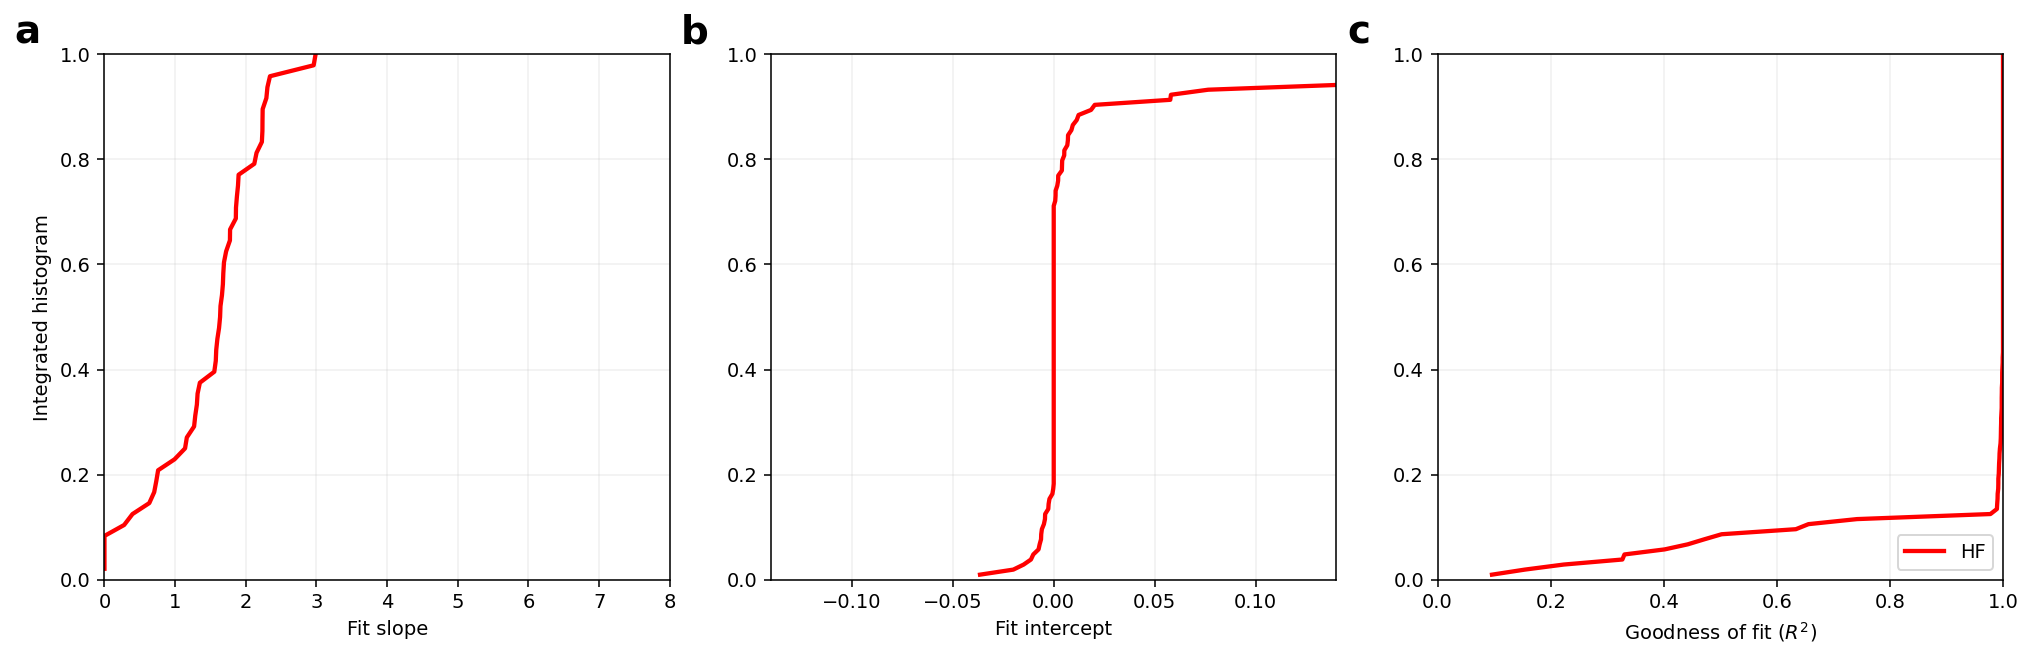

Terms total: 104
Panel a terms (excl. a≈b≈0): 48 (dropped 56)
Panel a slope (a): mean=1.500139, std=0.726497
All terms slope (a): mean=0.692372, std=0.896033
Intercept (b): mean=0.046229, std=0.194486
R^2: mean=0.930883, std=0.197520


In [9]:
# Cumulative histograms for LiH per-Pauli CDR fit coefficients (REM branch):
# exact_k ~= a_k * noisy_k + b_k
import numpy as np
import matplotlib.pyplot as plt

if "mit_pp" not in globals():
    raise RuntimeError("Run the CDR cell above first to create `mit_pp`.")

models = dict(mit_pp.get("cdr_models", {}))
coeffs_rem = np.asarray(models.get("coeffs_rem_to_exact_per_term", []), dtype=float)
r2_vals = np.asarray(models.get("r2_rem_to_exact_per_term", []), dtype=float)

if coeffs_rem.size == 0:
    raise RuntimeError("No per-Pauli coefficients found in mit_pp['cdr_models'].")
if coeffs_rem.ndim != 2 or coeffs_rem.shape[1] < 2:
    raise RuntimeError(f"Unexpected coeff shape: {coeffs_rem.shape}")
if r2_vals.size == 0:
    raise RuntimeError(
        "No per-Pauli R^2 values found. Re-run the CDR cell above after updating shot_measurement."
    )
if r2_vals.shape[0] != coeffs_rem.shape[0]:
    raise RuntimeError(
        f"R^2 length {r2_vals.shape[0]} != coefficient rows {coeffs_rem.shape[0]}"
    )

a_vals = np.asarray(coeffs_rem[:, 0], dtype=float)
b_vals = np.asarray(coeffs_rem[:, 1], dtype=float)

# Panel a only: exclude terms where both slope and intercept are ~0.
zero_pair_mask = np.isclose(a_vals, 0.0, atol=5e-3) & np.isclose(b_vals, 0.0, atol=5e-3)
a_vals_panel_a = a_vals[~zero_pair_mask]
if a_vals_panel_a.size == 0:
    raise RuntimeError("Panel a: all terms have both slope and intercept near zero (atol=5e-3).")


def _empirical_cdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(np.asarray(values, dtype=float))
    y = np.arange(1, len(x) + 1, dtype=float) / float(len(x))
    return x, y

x_a, y_a = _empirical_cdf(a_vals_panel_a)
x_b, y_b = _empirical_cdf(b_vals)
x_c, y_c = _empirical_cdf(r2_vals)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), dpi=140)
lih_color = "red"  # warm orange/yellow close to the reference figure

axes[0].plot(x_a, y_a, color=lih_color, lw=2.2, label="LiH")
axes[0].set_xlabel("Fit slope")
axes[0].set_ylabel("Integrated histogram")
axes[0].set_xlim(0, 8)
axes[0].set_ylim(0.0, 1.0)
axes[0].text(-0.16, 1.02, "a", transform=axes[0].transAxes, fontsize=20, fontweight="bold")

axes[1].plot(x_b, y_b, color=lih_color, lw=2.2, label="LiH")
axes[1].set_xlabel("Fit intercept")
axes[1].set_xlim(-0.14, 0.14)
axes[1].set_ylim(0.0, 1.0)
axes[1].text(-0.16, 1.02, "b", transform=axes[1].transAxes, fontsize=20, fontweight="bold")

axes[2].plot(x_c, y_c, color=lih_color, lw=2.2, label=globals().get("MOLECULE", "molecule"))
axes[2].set_xlabel(r"Goodness of fit ($R^2$)")
axes[2].set_xlim(0.0, 1.0)
axes[2].set_ylim(0.0, 1.0)
axes[2].text(-0.16, 1.02, "c", transform=axes[2].transAxes, fontsize=20, fontweight="bold")
axes[2].legend(loc="lower right", frameon=True)

for ax in axes:
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

print(f"Terms total: {len(a_vals)}")
print(f"Panel a terms (excl. a≈b≈0): {len(a_vals_panel_a)} (dropped {int(zero_pair_mask.sum())})")
print(f"Panel a slope (a): mean={np.mean(a_vals_panel_a):.6f}, std={np.std(a_vals_panel_a):.6f}")
print(f"All terms slope (a): mean={np.mean(a_vals):.6f}, std={np.std(a_vals):.6f}")
print(f"Intercept (b): mean={np.mean(b_vals):.6f}, std={np.std(b_vals):.6f}")
print(f"R^2: mean={np.mean(r2_vals):.6f}, std={np.std(r2_vals):.6f}")

## Parameter-shift gradients with CDR objective

For a pure expectation objective with `RX(θ) = exp(-i θ X / 2)`, the [parameter-shift rule](https://pennylane.ai/qml/glossary/parameter_shift)

$$\frac{\partial}{\partial \theta}\langle H \rangle = \frac{1}{2}\Big[\langle H \rangle(\theta + \pi/2) - \langle H \rangle(\theta - \pi/2)\Big]$$

is exact gate-by-gate.

In this section, `energy_from_params` defaults to the **CDR-corrected REM energy** objective (`cdr_rem_corrected`) so gradients are taken for the mitigated pipeline. Because this objective includes noisy-shot estimation + learned CDR correction, parameter-shift here is a **stochastic gradient estimator** (not an exact identity); we report it alongside the exact noiseless parameter-shift gradient as the reference direction. We do **not** finite-difference the CDR objective — dividing the shot/training noise by a small `eps` explodes the variance.

The strict correctness check runs on the **noiseless** objective, where parameter-shift is exact (each angle drives a single `RX` gate) and must match central finite differences. This only holds in double precision: the noiseless energy is evaluated with `cirq.Simulator(dtype=np.complex128)`, since the default single-precision (`complex64`) round-off floor (~`1e-5`), amplified by `1/eps`, would otherwise corrupt the finite-difference gradient.


In [10]:
# Gradients for the mitigated objective: CDR-corrected REM energy by default.
import numpy as np
import cirq

from main_cursor_lib import (
    CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
)

_grad_sim = cirq.Simulator(
    seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    dtype=np.complex128,
)
_PARAM_SHIFT = np.pi / 2.0
_DEFAULT_ENERGY_MODE = "cdr_rem_corrected"

# Independent shot-noise control. When True, every shot-energy evaluation draws a
# fresh sampling seed, so the noisy gradient sees genuine, uncorrelated shot noise
# (no common-random-number cancellation between the +/- parameter-shift terms).
# Set to False to recover the old deterministic-seed behaviour.
_VQE_INDEPENDENT_SAMPLING = True
_VQE_SEED_RNG = np.random.default_rng(int(globals().get("GLOBAL_SAMPLING_SEED", 1234)))


def _next_sampling_seed() -> int:
    if not _VQE_INDEPENDENT_SAMPLING:
        return int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"]))
    return int(_VQE_SEED_RNG.integers(1, 2**31 - 1))


def _resolver_from_params(params_vec: np.ndarray) -> dict:
    return resolver_from_params(params_vec)


def _noiseless_energy(params_vec: np.ndarray) -> float:
    """Exact noiseless statevector expectation ⟨H⟩."""
    resolver = cirq.ParamResolver(_resolver_from_params(params_vec))
    resolved = cirq.resolve_parameters(circuit, resolver)
    psi = np.asarray(
        _grad_sim.simulate(resolved, qubit_order=qubits).final_state_vector,
        dtype=np.complex128,
    )
    return float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))


def _cdr_rem_corrected_energy(params_vec: np.ndarray) -> float:
    """CDR-corrected REM target energy from ``run_mitigation(mode='cdr')``."""
    if "run_mitigation" not in globals():
        raise RuntimeError("run_mitigation not found. Run the CDR setup cell first.")

    resolver = _resolver_from_params(params_vec)
    symbols = globals().get("symbols_li_h", globals()["symbols"])

    base_noise = dict(
        globals().get(
            "base_noise_cfg",
            {
                "two_qubit_depol_prob": float(TWO_QUBIT_GATE_DEPOL_PROB),
                "one_qubit_depol_prob": float(ONE_QUBIT_GATE_DEPOL_PROB),
                "cross_chip_two_qubit_depol_prob": float(CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB),
            },
        )
    )
    shot_cfg_local = dict(globals().get("shot_cfg", {}))
    shot_cfg_local.setdefault("num_shots", int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])))
    shot_cfg_local.setdefault("measurement_scheme", str(globals()["GLOBAL_MEASUREMENT_SCHEME"]))
    shot_cfg_local.setdefault("apply_readout_noise", bool(globals()["GLOBAL_APPLY_READOUT_NOISE"]))
    shot_cfg_local["sampling_seed"] = _next_sampling_seed()

    readout_cal_local = dict(globals().get("readout_cal", {}))
    readout_cal_local.setdefault("p_0_success", np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float))
    readout_cal_local.setdefault("p_1_success", np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float))

    cdr_cfg_local = dict(
        globals().get(
            "cdr_cfg_base",
            {
                "num_circuits": int(globals()["CDR_NUM_TRAINING_CIRCUITS"]),
                "t_max": int(globals()["CDR_T_MAX_GRADIENT"]),
                "seed": int(globals()["CDR_BASE_SEED"]),
            },
        )
    )

    mit = run_mitigation(
        "cdr",
        ansatz_circuit=circuit,
        observable_h=pauli_sum,
        qubits=qubits,
        target_resolver=resolver,
        target_params=resolver,
        symbols=symbols,
        base_noise_cfg=base_noise,
        shot_cfg=shot_cfg_local,
        readout_cal=readout_cal_local,
        cdr_cfg=cdr_cfg_local,
        simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    )
    return float(mit["cdr_rem_corrected"])


def energy_from_params(params_vec: np.ndarray, energy_mode: str = _DEFAULT_ENERGY_MODE) -> float:
    """Objective energy at params.

    Supported modes:
      - ``cdr_rem_corrected`` (default): mitigated target from CDR + REM
      - ``noiseless``: exact statevector expectation
    """
    mode = str(energy_mode).strip().lower()
    if mode in {"cdr", "cdr_rem", "cdr_rem_corrected"}:
        return _cdr_rem_corrected_energy(params_vec)
    if mode in {"noiseless", "exact", "statevector"}:
        return _noiseless_energy(params_vec)
    raise ValueError(f"Unsupported energy_mode={energy_mode!r}.")


def parameter_shift_gradient(params_vec: np.ndarray, energy_mode: str = _DEFAULT_ENERGY_MODE) -> np.ndarray:
    """Gradient estimator via ±π/2 shifts (exact only for pure expectation objectives)."""
    g = np.zeros(n_params, dtype=float)
    p = np.asarray(params_vec, dtype=float).reshape(n_params)
    for i in range(n_params):
        plus = p.copy()
        minus = p.copy()
        plus[i] += _PARAM_SHIFT
        minus[i] -= _PARAM_SHIFT
        g[i] = 0.5 * (
            energy_from_params(plus, energy_mode=energy_mode)
            - energy_from_params(minus, energy_mode=energy_mode)
        )
    return g


def finite_difference_gradient(
    params_vec: np.ndarray,
    eps: float = 2e-2,
    energy_mode: str = _DEFAULT_ENERGY_MODE,
) -> np.ndarray:
    """Central finite-difference gradient for the selected objective."""
    g = np.zeros(n_params, dtype=float)
    p = np.asarray(params_vec, dtype=float).reshape(n_params)
    for i in range(n_params):
        plus = p.copy()
        minus = p.copy()
        plus[i] += eps
        minus[i] -= eps
        g[i] = (
            energy_from_params(plus, energy_mode=energy_mode)
            - energy_from_params(minus, energy_mode=energy_mode)
        ) / (2.0 * eps)
    return g


In [11]:
# # Gradient checks for the parameter-shift implementation:
# #   1) CDR-corrected REM objective -> informational (stochastic estimator)
# #   2) Noiseless objective         -> strict assertion (parameter-shift is exact)
# #
# # Each variational angle enters the compiled ansatz through a single RX(theta)
# # gate (coeff = 1), so on the *noiseless* objective the 2-term parameter-shift
# # rule is an exact identity and central finite differences must agree with it.
# # Finite differences are deliberately NOT used on the CDR objective: it is a
# # stochastic estimator (shot sampling + random Clifford training circuits), and
# # dividing that noise by a small eps blows the variance up into meaningless
# # numbers. The meaningful CDR diagnostic is whether its parameter-shift gradient
# # tracks the exact noiseless parameter-shift gradient.

# _ps_params = np.asarray(
#     globals().get(
#         "params",
#         np.array([-0.444980732142, 0.476365247616, 0.142686033100], dtype=float), # a random params array
#     ),
#     dtype=float,
# ).reshape(n_params)

# # --- 1) CDR-corrected REM objective (informational) ---------------------------
# _cdr_required = ["run_mitigation", "base_noise_cfg", "shot_cfg", "readout_cal", "symbols_li_h"]
# _cdr_missing = [name for name in _cdr_required if name not in globals()]
# if _cdr_missing:
#     raise RuntimeError(
#         "CDR objective needs the CDR setup cell first. Missing globals: "
#         + ", ".join(_cdr_missing)
#     )

# cdr_energy = energy_from_params(_ps_params, energy_mode="cdr_rem_corrected")
# cdr_ps_grad = parameter_shift_gradient(_ps_params, energy_mode="cdr_rem_corrected")
# # Exact noiseless gradient (parameter-shift) reused as the reference direction.
# noiseless_ps_grad = parameter_shift_gradient(_ps_params, energy_mode="noiseless")

# print("[CDR-corrected REM objective]  (informational: stochastic estimator)")
# print("objective energy:", cdr_energy)
# print("params:", _ps_params)
# print("CDR parameter-shift grad      :", cdr_ps_grad)
# print("noiseless parameter-shift grad:", noiseless_ps_grad)
# print("abs diff |cdr - noiseless|    :", np.abs(cdr_ps_grad - noiseless_ps_grad))

# # --- 2) Noiseless objective (strict: parameter-shift == finite difference) -----
# # Parameter-shift is exact here, so this is a genuine correctness check. It only
# # passes because the noiseless energy is evaluated in double precision
# # (cirq.Simulator(dtype=np.complex128)); in single precision the ~1e-5 round-off
# # floor, amplified by 1/eps, would corrupt the finite-difference gradient.
# _ref_fd_eps = 5e-3
# ref_fd_grad = finite_difference_gradient(_ps_params, eps=_ref_fd_eps, energy_mode="noiseless")

# print("\n[Noiseless reference check]  (parameter-shift is exact for single-RX angles)")
# print("parameter_shift grad:", noiseless_ps_grad)
# print(f"finite_difference grad (eps={_ref_fd_eps}):", ref_fd_grad)
# print("abs diff |ps - fd|:", np.abs(noiseless_ps_grad - ref_fd_grad))

# _ref_atol = 1e-4
# np.testing.assert_allclose(noiseless_ps_grad, ref_fd_grad, rtol=0.0, atol=_ref_atol)
# print("OK: noiseless parameter-shift matches finite differences within atol =", _ref_atol)


## VQE with CDR+REM + parameter-shift (fixed LR)

This section implements the workflow from the paper figure:

1. **Gradient**: estimate $\partial E/\partial \theta_i$ with the **parameter-shift** recipe using the **CDR-corrected REM** objective $E(\theta)=\texttt{cdr\_rem\_corrected}$ from `run_mitigation("cdr", ...)`.
2. **Full update**: each iteration, evaluate gradients for **all 3 trainable RX angles** and apply a **fixed learning-rate** update $\theta \leftarrow \theta - \eta\, \nabla E$ on all coordinates.
3. **Energy record**: after the update, evaluate $E(\theta)$ again and append to the optimisation trace.
4. **Stop**: run exactly `15` iterations.


**Energy evaluation counting**: every call to `energy_from_params(..., "cdr_rem_corrected")` counts as **one outer objective evaluation** (each runs a full CDR pipeline including inner shot sampling). With $N=3$, each main iteration uses $2N+1=7$ outer objective evaluations (init + 15 iters + final).


In [12]:
# --- VQE configuration (CDR+REM + parameter-shift + fixed LR) ---

# Optimisation (fixed length)
VQE_ITERS = 15

# Fixed learning rate (gradient descent on parameter-shift gradients)
VQE_LR = 0.5
NOISELESS_REF_LR = VQE_LR

# Require upstream CDR globals (run the CDR setup cell first)
_req = ["run_mitigation", "base_noise_cfg", "shot_cfg", "readout_cal", "symbols", "circuit", "pauli_sum", "qubits", "resolver_from_params"]
_miss = [n for n in _req if n not in globals()]
if _miss:
    raise RuntimeError("Missing notebook globals: " + ", ".join(_miss))


In [13]:
# --- VQE loop: fixed-LR gradient descent + full 3-parameter updates ---
import numpy as np

from main_cursor_lib import (
    CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
)

_ENERGY_MODE = "cdr_rem_corrected"

# Count every outer ``cdr_rem_corrected`` objective evaluation (``energy_from_params`` / ``run_mitigation``).
_n_energy_total = 0
_n_init = 0
_n_warmup = 0
_n_main_grad = 0
_n_main_post = 0
_n_final = 0
_n_noiseless_track = 0


def _vqe_energy(p, bucket: str) -> float:
    global _n_energy_total
    _n_energy_total += 1
    if bucket == "init":
        global _n_init
        _n_init += 1
    elif bucket == "warmup":
        global _n_warmup
        _n_warmup += 1
    elif bucket == "main_grad":
        global _n_main_grad
        _n_main_grad += 1
    elif bucket == "main_post":
        global _n_main_post
        _n_main_post += 1
    elif bucket == "final":
        global _n_final
        _n_final += 1
    else:
        raise ValueError(bucket)
    return float(energy_from_params(np.asarray(p, dtype=float).reshape(n_params), energy_mode=_ENERGY_MODE))


def _vqe_run_mitigation_triple(p, bucket: str) -> tuple[float, float, float]:
    """One ``run_mitigation("cdr", ...)`` call -> (raw finite-shot, REM, REM+CF)."""
    global _n_energy_total
    _n_energy_total += 1
    if bucket == "init":
        global _n_init
        _n_init += 1
    elif bucket == "warmup":
        global _n_warmup
        _n_warmup += 1
    elif bucket == "main_post":
        global _n_main_post
        _n_main_post += 1
    elif bucket == "final":
        global _n_final
        _n_final += 1
    else:
        raise ValueError(bucket)

    pv = np.asarray(p, dtype=float).reshape(n_params)
    resolver = resolver_from_params(pv)
    symbols = globals().get("symbols_li_h", globals()["symbols"])
    base_noise = dict(
        globals().get(
            "base_noise_cfg",
            {
                "two_qubit_depol_prob": float(TWO_QUBIT_GATE_DEPOL_PROB),
                "one_qubit_depol_prob": float(ONE_QUBIT_GATE_DEPOL_PROB),
                "cross_chip_two_qubit_depol_prob": float(CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB),
            },
        )
    )
    shot_cfg_local = dict(globals().get("shot_cfg", {}))
    shot_cfg_local.setdefault("num_shots", int(globals().get("num_shots", globals()["GLOBAL_NUM_SHOTS"])))
    shot_cfg_local.setdefault("measurement_scheme", str(globals()["GLOBAL_MEASUREMENT_SCHEME"]))
    shot_cfg_local.setdefault("apply_readout_noise", bool(globals()["GLOBAL_APPLY_READOUT_NOISE"]))
    shot_cfg_local["sampling_seed"] = _next_sampling_seed()
    readout_cal_local = dict(globals().get("readout_cal", {}))
    readout_cal_local.setdefault("p_0_success", np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float))
    readout_cal_local.setdefault("p_1_success", np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float))
    cdr_cfg_local = dict(
        globals().get(
            "cdr_cfg_base",
            {
                "num_circuits": int(globals()["CDR_NUM_TRAINING_CIRCUITS"]),
                "t_max": int(globals()["CDR_T_MAX_VQE"]),
                "seed": int(globals()["CDR_BASE_SEED"]),
            },
        )
    )

    mit = run_mitigation(
        "cdr",
        ansatz_circuit=circuit,
        observable_h=pauli_sum,
        qubits=qubits,
        target_resolver=resolver,
        target_params=resolver,
        symbols=symbols,
        base_noise_cfg=base_noise,
        shot_cfg=shot_cfg_local,
        readout_cal=readout_cal_local,
        cdr_cfg=cdr_cfg_local,
        simulator_seed=int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"])),
    )
    return float(mit["unmit_target"]), float(mit["rem_target"]), float(mit["cdr_rem_corrected"])


def _vqe_noiseless(p) -> float:
    """Exact statevector ⟨H⟩ at the same parameters (not counted in ``_n_energy_total``)."""
    global _n_noiseless_track
    _n_noiseless_track += 1
    _pv = np.asarray(p, dtype=float).reshape(n_params)
    return float(energy_from_params(_pv, energy_mode="noiseless"))


def _vqe_param_shift_grad(p, bucket: str) -> np.ndarray:
    g = np.zeros(n_params, dtype=float)
    pv = np.asarray(p, dtype=float).reshape(n_params)
    h = float(_PARAM_SHIFT)
    for i in range(n_params):
        pp = pv.copy()
        pm = pv.copy()
        pp[i] += h
        pm[i] -= h
        g[i] = 0.5 * (_vqe_energy(pp, bucket) - _vqe_energy(pm, bucket))
    return g


# Initial guess (all-zero parameters = the reference state)
_params0 = np.zeros(n_params, dtype=float)
print(f"[VQE] initial params ({n_params} angles) = {_params0.tolist()}")

P = n_params

# Real-machine cost model for one CDR objective call.
# In this notebook's CDR path (per-pauli fit), one run_mitigation('cdr') evaluates shot energies
# approximately (num_circuits + 2) times:
#   - num_circuits training circuits, plus
#   - 2 target baseline evaluations (one early baseline + one per-term baseline).
_shot_cfg_local = dict(globals().get("shot_cfg", {}))
_cdr_cfg_local = dict(globals().get("cdr_cfg_base", {}))
_num_shots = int(_shot_cfg_local.get("num_shots", globals()["num_shots"]))
_num_circuits = int(_cdr_cfg_local.get("num_circuits", globals()["CDR_NUM_TRAINING_CIRCUITS"]))
_energy_evals_per_cdr_call = int(_num_circuits + 1)
_shots_per_cdr_call = int(_energy_evals_per_cdr_call * _num_shots)

print(
    f"[VQE] Cost model per CDR objective call: energy-evals={_energy_evals_per_cdr_call} "
    f"(num_circuits={_num_circuits} + 1), shots/eval={_num_shots}, "
    f"shots/call={_shots_per_cdr_call}"
)

# Baseline (iteration 0): one mitigation triple + exact noiseless ⟨H⟩ at θ₀
energy_curves: list[dict] = []
raw0, rem0, cdr0 = _vqe_run_mitigation_triple(_params0, "init")
E0 = float(cdr0)
nls0 = float(_vqe_noiseless(_params0))
energy_curves.append(
    {
        "iter": 0,
        "raw_eh": float(raw0),
        "rem_eh": float(rem0),
        "rem_cf_eh": float(cdr0),
        "noiseless_eh": float(nls0),
    }
)

VQE_LR = float(VQE_LR)
_NOISELESS_REF_LR = float(NOISELESS_REF_LR)
print(f"[VQE] fixed VQE_LR={VQE_LR:g} (CDR+REM main loop)")
print(f"[VQE] noiseless reference LR={_NOISELESS_REF_LR:g} (decoupled exact reference curve)")

# Decoupled exact reference: noiseless-only fixed-LR + parameter-shift.


def _build_noiseless_reference_curve(params_start: np.ndarray, iters: int):
    th = np.asarray(params_start, dtype=float).reshape(n_params).copy()
    out = [float(_vqe_noiseless(th))]
    thetas = [th.copy()]
    for _ in range(int(iters)):
        g_ref = parameter_shift_gradient(th, energy_mode="noiseless")
        th = th - float(_NOISELESS_REF_LR) * g_ref
        out.append(float(_vqe_noiseless(th)))
        thetas.append(th.copy())
    return out, thetas


noiseless_ref_curve, noiseless_ref_thetas = _build_noiseless_reference_curve(_params0, int(VQE_ITERS))

# --- Main optimisation (fixed exactly VQE_ITERS iterations) ---
theta = _params0.copy()

trace = []
best_E = float("inf")
best_theta = theta.copy()
prev_E = float(E0)

for it in range(1, int(VQE_ITERS) + 1):
    _count_before = int(_n_energy_total)
    theta_before = theta.copy()
    active = np.arange(P, dtype=int)
    g = _vqe_param_shift_grad(theta, "main_grad")
    theta = theta - float(VQE_LR) * g
    raw_e, rem_e, E = _vqe_run_mitigation_triple(theta, "main_post")
    nls_e = float(noiseless_ref_curve[int(it)])
    dE = float(E) - float(prev_E)

    # --- Diagnostics: isolate the effect of noise on the gradient vs the params ---
    # g was computed on the noisy (CDR+REM) objective at theta_before; compare it to
    # the *exact* parameter-shift gradient at the SAME point. A tiny ||g_noisy - g_noiseless||
    # alongside a ~1e-2 absolute REM+CF energy bias confirms the bias cancels in the
    # +/- shift difference. theta_diff compares the two (decoupled) GD trajectories.
    g_noiseless_same = parameter_shift_gradient(theta_before, energy_mode="noiseless")
    grad_diff = float(np.linalg.norm(g - g_noiseless_same))
    grad_noisy_norm = float(np.linalg.norm(g))
    theta_diff = float(np.linalg.norm(theta - noiseless_ref_thetas[int(it)]))
    nls_at_theta = float(_vqe_noiseless(theta))
    e_bias = abs(float(E) - nls_at_theta)

    energy_curves.append(
        {
            "iter": int(it),
            "raw_eh": float(raw_e),
            "rem_eh": float(rem_e),
            "rem_cf_eh": float(E),
            "noiseless_eh": float(nls_e),
        }
    )

    trace.append(
        {
            "iter": int(it),
            "energy": float(E),
            "raw_eh": float(raw_e),
            "rem_eh": float(rem_e),
            "noiseless_eh": float(nls_e),
            "theta": theta.copy(),
            "grad": g.copy(),
            "active": active.copy(),
            "dE": float(dE),
            "grad_diff": grad_diff,
            "grad_noisy_norm": grad_noisy_norm,
            "theta_diff": theta_diff,
            "e_bias": e_bias,
        }
    )

    if E < best_E:
        best_E = float(E)
        best_theta = theta.copy()

    step_vec = theta_before - theta
    step_l2 = float(np.linalg.norm(step_vec)) if step_vec.size else 0.0
    step_max = float(np.max(np.abs(step_vec))) if step_vec.size else 0.0

    cdr_calls_this_iter = int(_n_energy_total - _count_before)
    cum_cdr_calls = int(_n_energy_total)
    cum_energy_evals = int(cum_cdr_calls * _energy_evals_per_cdr_call)
    cum_shots = int(cum_cdr_calls * _shots_per_cdr_call)
    grad_str = np.array2string(g, precision=6, separator=", ")
    theta_updated = np.array2string(theta, precision=6, separator=", ")

    print(
        f"[VQE] iter={it:02d}  lr={float(VQE_LR):.5g}  E={E:.8f}  dE={dE:+.3e}  "
        f"grad={grad_str}  step_max={step_max:.3e}  step_l2={step_l2:.3e}  active={active.tolist()}  "
        f"theta={theta_updated}  cdr_calls_iter={cdr_calls_this_iter}  "
        f"cdr_calls_cum={cum_cdr_calls}  energy_evals_cum≈{cum_energy_evals}  shots_cum≈{cum_shots}"
    )
    print(
        f"[VQE-diag] iter={it:02d}  "
        f"||g_noisy - g_noiseless||={grad_diff:.3e}  "
        f"||g_noisy||={grad_noisy_norm:.3e}  "
        f"||theta_noisy - theta_noiseless||={theta_diff:.3e}  "
        f"|REM+CF - noiseless|@theta={e_bias:.3e}"
    )
    prev_E = float(E)

_, _, E_final = _vqe_run_mitigation_triple(theta, "final")

_total_cdr_calls = int(_n_energy_total)
_total_energy_evals = int(_total_cdr_calls * _energy_evals_per_cdr_call)
_total_shots = int(_total_cdr_calls * _shots_per_cdr_call)
print(
    f"[VQE] TOTAL measurement cost: cdr_calls={_total_cdr_calls}, "
    f"energy_evals≈{_total_energy_evals}, total_shots≈{_total_shots}"
)

vqe_results = {
    "params_init": _params0.copy(),
    "params_final": theta.copy(),
    "params_best": best_theta.copy(),
    "E_init": float(E0),
    "E_final": float(E_final),
    "E_best": float(best_E),
    "trace": trace,
    "energy_curves": energy_curves,
    "lr": float(VQE_LR),
    "noiseless_ref_lr": float(_NOISELESS_REF_LR),
    "max_iters": int(VQE_ITERS),
    "executed_iters": int(trace[-1]["iter"]) if trace else 0,
    "counts": {
        "total": int(_n_energy_total),
        "init": int(_n_init),
        "warmup": int(_n_warmup),
        "main_grad": int(_n_main_grad),
        "main_post": int(_n_main_post),
        "final": int(_n_final),
        "noiseless_track": int(_n_noiseless_track),
    },
    "cost_model": {
        "num_circuits": int(_num_circuits),
        "num_shots_per_eval": int(_num_shots),
        "energy_evals_per_cdr_call": int(_energy_evals_per_cdr_call),
        "shots_per_cdr_call": int(_shots_per_cdr_call),
        "total_cdr_calls": int(_total_cdr_calls),
        "total_energy_evals_est": int(_total_energy_evals),
        "total_shots_est": int(_total_shots),
    },
}


[VQE] initial params (3 angles) = [0.0, 0.0, 0.0]
[VQE] Cost model per CDR objective call: energy-evals=31 (num_circuits=30 + 1), shots/eval=8192, shots/call=253952
[VQE] fixed VQE_LR=0.5 (CDR+REM main loop)
[VQE] noiseless reference LR=0.5 (decoupled exact reference curve)
[VQE] iter=01  lr=0.5  E=-98.59023193  dE=-3.184e-02  grad=[-0.137665, -0.022203, -0.032359]  step_max=6.883e-02  step_l2=7.157e-02  active=[0, 1, 2]  theta=[0.068832, 0.011102, 0.016179]  cdr_calls_iter=7  cdr_calls_cum=8  energy_evals_cum≈248  shots_cum≈2031616
[VQE-diag] iter=01  ||g_noisy - g_noiseless||=8.749e-02  ||g_noisy||=1.431e-01  ||theta_noisy - theta_noiseless||=4.374e-02  |REM+CF - noiseless|@theta=5.219e-02
[VQE] iter=02  lr=0.5  E=-98.56388788  dE=+2.634e-02  grad=[-0.185347, -0.068109,  0.024363]  step_max=9.267e-02  step_l2=9.948e-02  active=[0, 1, 2]  theta=[0.161506, 0.045156, 0.003998]  cdr_calls_iter=7  cdr_calls_cum=15  energy_evals_cum≈465  shots_cum≈3809280
[VQE-diag] iter=02  ||g_noisy - g_

In [14]:

# # --- VQE report: trace + energy-evaluation accounting ---
# import numpy as np

# vr = vqe_results
# c = vr["counts"]

# print("\n=== VQE summary (CDR+REM objective) ===")
# print(f"chosen lr={vr['lr']:.6g}  noiseless_ref_lr={vr.get('noiseless_ref_lr')}")
# print(f"E_init={vr['E_init']:.10f} Eh")
# print(f"E_best={vr['E_best']:.10f} Eh  (tracked during main loop)")
# print(f"E_final_recheck={vr['E_final']:.10f} Eh")
# print(f"params_init={vr['params_init'].tolist()}")
# print(f"params_best={vr['params_best'].tolist()}")
# print(f"params_final={vr['params_final'].tolist()}")
# print(f"executed_iters={vr['executed_iters']} / max_iters={vr['max_iters']}")

# print("\n=== Optimisation trace ===")
# for row in vr["trace"]:
#     print(
#         f"iter={row['iter']:02d}  E={row['energy']:.10f}  |g|_max={np.max(np.abs(row['grad'])):.3e}  active={row['active'].tolist()}"
#     )

# P = n_params
# T = int(vr["executed_iters"])
# formula = int(c["init"]) + int(c["warmup"]) + int(c["main_grad"]) + int(c["main_post"]) + int(c["final"])
# print("\n=== Outer energy evaluation counts ===")
# print(
#     "Each count is one call to energy_from_params(..., 'cdr_rem_corrected') "
#     "(internally runs CDR+REM shot pipeline)."
# )
# print(f"n_init={c['init']}")
# print(f"n_warmup={c['warmup']}")
# print(f"n_main_grad={c['main_grad']}  (should be {T} * {2*P} = {T*2*P})")
# print(f"n_main_post={c['main_post']}  (should be {T} * 1 = {T})")
# print(f"n_final={c['final']}")
# print(f"n_total_accounted={formula}")
# print(f"n_total_runtime_counter={c['total']}")
# assert int(c["total"]) == int(formula), "count mismatch"

# # Closed-form expectation for the main loop structure (for transparency)
# print("\n=== Reference formulas (main loop only) ===")
# print(f"Per main iter: parameter-shift uses 2P={2*P} evals; post-update energy uses +1 => {2*P+1} evals/iter")
# print(f"If all {vr['max_iters']} iters ran: init(optional) + {vr['max_iters']}*({2*P}+1) + final(optional)")

# if "e_test" in globals():
#     print(f"\nnoiseless reference e_test={float(e_test):.10f} Eh  (not the optimised objective)")


Using true GS reference energy: -98.573878336679 Eh


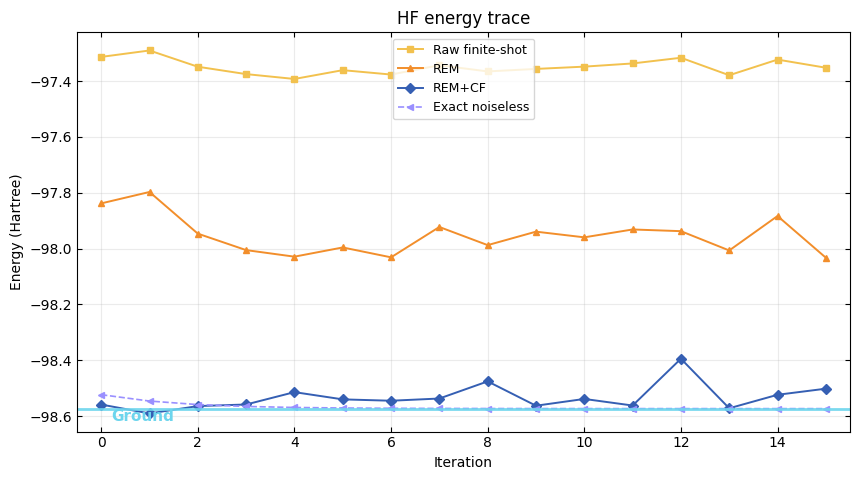

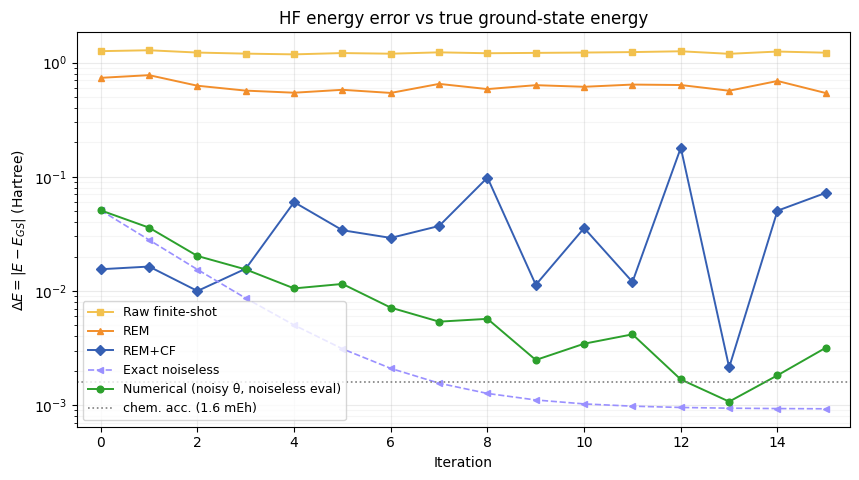

In [15]:
# --- VQE plots (panel-b style): energy + log-scale error vs true GS ---
import matplotlib.pyplot as plt
import numpy as np

if "vqe_results" not in globals():
    raise RuntimeError("Run the VQE loop cell first (defines vqe_results).")

ec = vqe_results["energy_curves"]
xs = np.asarray([float(r["iter"]) for r in ec], dtype=float)
raw = np.asarray([float(r["raw_eh"]) for r in ec], dtype=float)
rem = np.asarray([float(r["rem_eh"]) for r in ec], dtype=float)
cf = np.asarray([float(r["rem_cf_eh"]) for r in ec], dtype=float)
nls = np.asarray([float(r["noiseless_eh"]) for r in ec], dtype=float)

# True ground-state energy reference (main.ipynb defines e_gs).
if "e_gs" in globals():
    e_ref = float(e_gs)
elif "true_gs_energy" in globals():
    e_ref = float(true_gs_energy)
else:
    e_ref = float(np.linalg.eigvalsh(pauli_sum.matrix(qubits=qubits))[0].real)

style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="REM+CF")
style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless")
style_num = dict(color="#2ca02c", marker="o", ms=4.8, lw=1.4, label="Numerical (noisy θ, noiseless eval)")

# "Numerical": params found by the noisy optimizer, re-evaluated with the exact noiseless energy.
thetas_noisy = [np.asarray(vqe_results["params_init"], dtype=float)]
thetas_noisy += [np.asarray(r["theta"], dtype=float) for r in vqe_results["trace"]]
num = np.asarray(
    [float(energy_from_params(th.reshape(n_params), energy_mode="noiseless")) for th in thetas_noisy],
    dtype=float,
)

# ---- Energy trace ----
fig1, ax1 = plt.subplots(figsize=(8.7, 4.9))
ax1.plot(xs, raw, **style_raw)
ax1.plot(xs, rem, **style_rem)
ax1.plot(xs, cf, **style_cf)
ax1.plot(xs, nls, **style_nls)
ax1.axhline(e_ref, color="#6dd5ed", lw=2.0, alpha=0.9)
ax1.text(xs.min() + 0.2, e_ref, "Ground", color="#6dd5ed",
         va="top", ha="left", fontsize=11, weight="bold")

# Auto y-limits with a little padding.
all_e = np.concatenate([raw, rem, cf, nls, [e_ref]])
lo, hi = float(all_e.min()), float(all_e.max())
pad = 0.05 * (hi - lo + 1e-9)
ax1.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
ax1.set_ylim(lo - pad, hi + pad)
ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Energy (Hartree)")
ax1.set_title("HF energy trace")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="best", fontsize=9)
fig1.tight_layout()

# ---- Absolute error vs true GS (log-y) ----
floor = 1e-16
err_raw = np.maximum(np.abs(raw - e_ref), floor)
err_rem = np.maximum(np.abs(rem - e_ref), floor)
err_cf = np.maximum(np.abs(cf - e_ref), floor)
err_nls = np.maximum(np.abs(nls - e_ref), floor)
err_num = np.maximum(np.abs(num - e_ref), floor)

fig2, ax2 = plt.subplots(figsize=(8.7, 4.9))
ax2.plot(xs, err_raw, **style_raw)
ax2.plot(xs, err_rem, **style_rem)
ax2.plot(xs, err_cf, **style_cf)
ax2.plot(xs, err_nls, **style_nls)
ax2.plot(xs, err_num, **style_num)
ax2.set_yscale("log")
ax2.axhline(1.6e-3, color="gray", ls=":", lw=1.2, label="chem. acc. (1.6 mEh)")
ax2.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
ax2.set_title("HF energy error vs true ground-state energy")
ax2.grid(True, which="major", alpha=0.25)
ax2.grid(True, which="minor", alpha=0.12)
ax2.legend(loc="best", fontsize=9)
fig2.tight_layout()

print(f"Using true GS reference energy: {e_ref:.12f} Eh")
plt.show()

In [16]:
# --- Connected Moment Expansion (CME), order k=3 ---
# E_ground = <H> - (<H^2> - <H>^2)^2 / (<H^3> - 3<H><H^2> + 2<H>^3)
#
# Quantum state: the FINAL noisy state after the 15-step VQE (gate noise + the
# optimized final parameters). <H>, <H^2> and <H^3> are each measured with the
# SAME CDR+REM pipeline used for the VQE energy objective (run_mitigation("cdr"))
# -- one call per observable, each with its own Hamiltonian file, OGM basis file
# and shot budget. CDR rebuilds the noisy state internally from `circuit` + the
# final-parameter resolver + the same noise model and simulator seed, i.e. the
# identical final noisy state as `rho_final` (kept here only for the exact
# Tr[H^k rho] reference).
#
# Accuracy is judged against the EXACT NOISELESS expectation <psi|H^k|psi> at the
# final params (mirrors the VQE loop's |REM+CF - noiseless| diagnostic), because
# CDR+REM recovers the noiseless value -- not the noisy-state Tr[H^k rho_final].
import sys
from pathlib import Path

import cirq
import numpy as np

_repo = Path.cwd().resolve()
while not (_repo / "June_main" / "main_cursor_lib.py").is_file() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (str(_repo / "June_main"), str(_repo)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib import (
    GateArityDepolarizingNoise,
    CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    trace_energy,
)
from shot_measurement import run_mitigation, sanitize_density_matrix

# ----------------------------------------------------------------------------
# Per-observable shot budgets. <H^2> and <H^3> are much harder to estimate than
# <H> (larger coefficients + many more Pauli terms), so they get their OWN, much
# bigger shot counts here instead of the single GLOBAL_NUM_SHOTS knob (cell :18).
# Tune these freely.
# ----------------------------------------------------------------------------
CME_H_NUM_SHOTS = int(globals().get("GLOBAL_NUM_SHOTS", 8192))   # shots for <H>
CME_H2_NUM_SHOTS = 81920                                        # shots for <H^2>
CME_H3_NUM_SHOTS = 81920                                       # shots for <H^3>

# Which measured value feeds the CME formula, one of:
#   "cdr_rem"   -> CDR + REM corrected (matches the VQE energy objective)
#   "cdr_unmit" -> CDR corrected on the raw (non-REM) finite-shot energy
#   "rem"       -> REM only (no CDR)
#   "unmit"     -> raw finite-shot (no mitigation)
CME_MOMENT_SOURCE = "cdr_rem"

if "vqe_results" not in globals():
    raise RuntimeError("Run the VQE loop cell first (defines vqe_results).")

# 1) Rebuild the FINAL noisy density matrix from the optimized VQE parameters
#    (same noisy-ansatz + density-matrix recipe as cell ``21b206da``).
random_seed = int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"]))
params_final = np.asarray(vqe_results["params_final"], dtype=float).reshape(n_params)

gate_noise = GateArityDepolarizingNoise(
    two_qubit_depol_prob=TWO_QUBIT_GATE_DEPOL_PROB,
    one_qubit_depol_prob=ONE_QUBIT_GATE_DEPOL_PROB,
    cross_chip_two_qubit_depol_prob=CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
)
_noisy_ansatz = circuit.with_noise(gate_noise)
_resolved_final = cirq.resolve_parameters(
    _noisy_ansatz, cirq.ParamResolver(resolver_from_params(params_final))
)
rho_final = np.asarray(
    cirq.DensityMatrixSimulator(seed=random_seed)
    .simulate(_resolved_final, qubit_order=qubits)
    .final_density_matrix,
    dtype=np.complex128,
)
rho_final = sanitize_density_matrix(rho_final)

# 1b) Exact NOISELESS statevector at the SAME final params. This is the reference
#     the VQE loop compares CDR+REM against (|REM+CF - noiseless|): CDR is built to
#     recover the noiseless expectation, so each moment's cdr+rem should be compared
#     to <psi|H^k|psi> here -- NOT to the noisy-state Tr[H^k rho_final] below.
_psi_noiseless = np.asarray(
    cirq.Simulator(dtype=np.complex128)
    .simulate(
        cirq.resolve_parameters(circuit, cirq.ParamResolver(resolver_from_params(params_final))),
        qubit_order=qubits,
    )
    .final_state_vector,
    dtype=np.complex128,
)
_qubit_map = {q: i for i, q in enumerate(qubits)}

# 2) Hamiltonian (H / H^2 / H^3) + matching OGM measurement-basis files.
ham_paths = {
    "H": _repo / "Pauli_Ham" / f"{MOLECULE}_bond_{bond_length:.1f}.txt",
    "H2": _repo / "Pauli_Ham" / f"{MOLECULE}_square_bond_{bond_length:.1f}.txt",
    "H3": _repo / "Pauli_Ham" / f"{MOLECULE}_triple_bond_{bond_length:.1f}.txt",
}
ogm_paths = {
    "H": _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_bond_{bond_length:.1f}.txt",
    "H2": _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_square_bond_{bond_length:.1f}.txt",
    "H3": _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_triple_bond_{bond_length:.1f}.txt",
}
shots = {"H": CME_H_NUM_SHOTS, "H2": CME_H2_NUM_SHOTS, "H3": CME_H3_NUM_SHOTS}

for key in ("H", "H2", "H3"):
    if not ham_paths[key].is_file():
        raise FileNotFoundError(f"Missing Hamiltonian file for {key}: {ham_paths[key]}")
    if not ogm_paths[key].is_file():
        raise FileNotFoundError(f"Missing OGM basis file for {key}: {ogm_paths[key]}")

# Reuse the already-loaded H PauliSum; load H^2 and H^3 from their numbered files.
pauli_sums = {
    "H": pauli_sum,
    "H2": load_pauli_sum_from_numbered_file(ham_paths["H2"], list(qubits)),
    "H3": load_pauli_sum_from_numbered_file(ham_paths["H3"], list(qubits)),
}

# 3) Mitigation config (CDR + REM), reused from the VQE objective so the moments
#    are measured exactly like the 15th VQE energy. Falls back to GLOBAL_* knobs
#    if the CDR-setup cell's globals are not present.
final_resolver = cirq.ParamResolver(resolver_from_params(params_final))
symbols_cme = globals().get("symbols_li_h", globals()["symbols"])

base_noise_cme = dict(
    globals().get(
        "base_noise_cfg",
        {
            "two_qubit_depol_prob": float(TWO_QUBIT_GATE_DEPOL_PROB),
            "one_qubit_depol_prob": float(ONE_QUBIT_GATE_DEPOL_PROB),
            "cross_chip_two_qubit_depol_prob": float(CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB),
        },
    )
)
readout_cal_cme = dict(globals().get("readout_cal", {}))
readout_cal_cme.setdefault("p_0_success", np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float))
readout_cal_cme.setdefault("p_1_success", np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float))
cdr_cfg_cme = dict(
    globals().get(
        "cdr_cfg_base",
        {
            "num_circuits": int(globals()["CDR_NUM_TRAINING_CIRCUITS"]),
            "t_max": int(globals()["CDR_T_MAX_VQE"]),
            "seed": int(globals()["CDR_BASE_SEED"]),
        },
    )
)
_base_shot_cfg = dict(globals().get("shot_cfg", {}))
_base_shot_cfg.setdefault("measurement_scheme", str(globals()["GLOBAL_MEASUREMENT_SCHEME"]))
_base_shot_cfg.setdefault("apply_readout_noise", bool(globals()["GLOBAL_APPLY_READOUT_NOISE"]))
_base_shot_cfg.setdefault("sampling_seed", int(globals()["GLOBAL_SAMPLING_SEED"]))
_base_shot_cfg.setdefault(
    "shadowgrouping_root", globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping")
)
_sim_seed = int(globals().get("random_seed", globals()["GLOBAL_RANDOM_SEED"]))
if not Path(_base_shot_cfg["shadowgrouping_root"]).is_dir():
    raise RuntimeError(f"SHADOWGROUPING_ROOT does not exist: {_base_shot_cfg['shadowgrouping_root']}")

# 4) Measure <H>, <H^2>, <H^3> with the CDR+REM pipeline (one run_mitigation per
#    observable, each with its own shot budget and OGM basis file).
moments = {k: {} for k in ("H", "H2", "H3")}
for key in ("H", "H2", "H3"):
    shot_cfg_key = dict(_base_shot_cfg)
    shot_cfg_key["num_shots"] = int(shots[key])
    shot_cfg_key["ogm_file"] = ogm_paths[key]
    mit = run_mitigation(
        "cdr",
        ansatz_circuit=circuit,
        observable_h=pauli_sums[key],
        qubits=qubits,
        target_resolver=final_resolver,
        target_params=final_resolver,
        symbols=symbols_cme,
        base_noise_cfg=base_noise_cme,
        shot_cfg=shot_cfg_key,
        readout_cal=readout_cal_cme,
        cdr_cfg=cdr_cfg_cme,
        simulator_seed=_sim_seed,
    )
    moments[key]["unmit"] = float(mit["unmit_target"])
    moments[key]["rem"] = float(mit["rem_target"])
    moments[key]["cdr_unmit"] = float(mit["cdr_unmit_corrected"])
    moments[key]["cdr_rem"] = float(mit["cdr_rem_corrected"])
    moments[key]["exact"] = float(trace_energy(pauli_sums[key].matrix(qubits=qubits), rho_final))
    moments[key]["noiseless"] = float(
        np.real(pauli_sums[key].expectation_from_state_vector(_psi_noiseless, qubit_map=_qubit_map))
    )
    print(
        f"<{key:<2}>  shots={int(shots[key]):>8d}  "
        f"cdr+rem={moments[key]['cdr_rem']:+.8f}  rem={moments[key]['rem']:+.8f}  "
        f"unmit={moments[key]['unmit']:+.8f}  noiseless={moments[key]['noiseless']:+.8f}  "
        f"noisy_exact={moments[key]['exact']:+.8f}  "
        f"|cdr+rem - noiseless|={abs(moments[key]['cdr_rem'] - moments[key]['noiseless']):.3e}"
    )


# 5) Connected moment expansion (k=3).
def _cme_k3(h1: float, h2: float, h3: float):
    c1 = h1
    c2 = h2 - h1 ** 2
    c3 = h3 - 3.0 * h1 * h2 + 2.0 * h1 ** 3
    e = float("nan") if abs(c3) < 1e-12 else c1 - (c2 ** 2) / c3
    return e, c1, c2, c3


src = {k: moments[k][CME_MOMENT_SOURCE] for k in ("H", "H2", "H3")}
E_cme, C1, C2, C3 = _cme_k3(src["H"], src["H2"], src["H3"])
E_cme_exact, _, _, _ = _cme_k3(moments["H"]["exact"], moments["H2"]["exact"], moments["H3"]["exact"])
E_cme_noiseless, _, _, _ = _cme_k3(
    moments["H"]["noiseless"], moments["H2"]["noiseless"], moments["H3"]["noiseless"]
)

e_ref = float(globals().get("e_gs", np.linalg.eigvalsh(pauli_sum.matrix(qubits=qubits))[0].real))

print("\n=== Connected Moment Expansion (k=3) on final VQE noisy state ===")
print(f"moment source for formula : {CME_MOMENT_SOURCE}")
print(f"<H>={src['H']:+.8f}  <H^2>={src['H2']:+.8f}  <H^3>={src['H3']:+.8f}")
print(f"connected moments         : c1={C1:+.6e}  c2={C2:+.6e}  c3={C3:+.6e}")
# Per-moment bias vs the NOISELESS reference, exactly like the VQE loop's
# |REM+CF - noiseless| diagnostic (this is the meaningful CDR+REM error).
print(
    "moment vs NOISELESS       : "
    + "  ".join(
        f"|<{k}>{CME_MOMENT_SOURCE} - <{k}>nls|={abs(moments[k][CME_MOMENT_SOURCE] - moments[k]['noiseless']):.3e}"
        for k in ("H", "H2", "H3")
    )
)
print(f"E_CME(k=3) [shots/{CME_MOMENT_SOURCE}]      = {E_cme:.10f} Eh")
print(f"E_CME(k=3) [noiseless moments] = {E_cme_noiseless:.10f} Eh")
print(f"E_CME(k=3) [exact Tr moments]  = {E_cme_exact:.10f} Eh")
print(f"true ground-state energy e_gs  = {e_ref:.10f} Eh")
print(f"|E_CME - e_gs|       (shots)    = {abs(E_cme - e_ref):.6e} Eh")
print(f"|<H>   - e_gs|       (shots)    = {abs(src['H'] - e_ref):.6e} Eh")
print(f"|<H>cdr+rem - <H>noiseless|     = {abs(src['H'] - moments['H']['noiseless']):.6e} Eh  (cf. VQE loop ~1e-2)")
print(f"|E_CME(shots) - E_CME(noiseless)| = {abs(E_cme - E_cme_noiseless):.6e} Eh")

cme_results = {
    "params_final": params_final.copy(),
    "shots": dict(shots),
    "moments": {k: dict(v) for k, v in moments.items()},
    "connected_moments": {"c1": float(C1), "c2": float(C2), "c3": float(C3)},
    "E_cme_shots": float(E_cme),
    "E_cme_noiseless": float(E_cme_noiseless),
    "E_cme_exact": float(E_cme_exact),
    "e_gs": float(e_ref),
    "moment_source": CME_MOMENT_SOURCE,
}

<H >  shots=    8192  cdr+rem=-98.51433023  rem=-98.02153217  unmit=-97.37369971  noiseless=-98.57069788  noisy_exact=-97.95216911  |cdr+rem - noiseless|=5.637e-02
<H2>  shots=   81920  cdr+rem=+9712.94052307  rem=+9602.14712847  unmit=+9480.48963792  noiseless=+9716.19034790  noisy_exact=+9595.62124768  |cdr+rem - noiseless|=3.250e+00
<H3>  shots=   81920  cdr+rem=-957440.52944888  rem=-941869.48372738  unmit=-923333.47903756  noiseless=-957733.17484550  noisy_exact=-940103.28072344  |cdr+rem - noiseless|=2.926e+02

=== Connected Moment Expansion (k=3) on final VQE noisy state ===
moment source for formula : cdr_rem
<H>=-98.51433023  <H^2>=+9712.94052307  <H^3>=-957440.52944888
connected moments         : c1=-9.851433e+01  c2=+7.867263e+00  c3=+9.733770e+02
moment vs NOISELESS       : |<H>cdr_rem - <H>nls|=5.637e-02  |<H2>cdr_rem - <H2>nls|=3.250e+00  |<H3>cdr_rem - <H3>nls|=2.926e+02
E_CME(k=3) [shots/cdr_rem]      = -98.5779169227 Eh
E_CME(k=3) [noiseless moments] = -98.5722644506 E